In [ ]:
# ---------------------------------------------------------
# Environment Setup and Initialization
# ---------------------------------------------------------
using LinearAlgebra
using Plots
using Printf
using Statistics
using Revise
using JLD2

In [ ]:
# Include custom modules containing the proposed method, baselines, and evaluation metrics
includet("../julia_source/myGenerateData.jl")
includet("../julia_source/myLoadVideo.jl")
includet("../julia_source/myTTD.jl")
includet("../julia_source/myIndicator.jl")

In [ ]:
# ---------------------------------------------------------
# Load Experimental Results (Synthetic Data)
# ---------------------------------------------------------
# Define the experimental parameters (e.g., N=5, T=100)
n = 5
T = 100

# Load the pre-computed relative errors and execution times from the ablation study.
# This serialized data is generated by the execution notebook (ALS_synthetic.ipynb).
@load "rebuttal/ALS_synthetic_results_$n.jld2" relative_error_ALS relative_error_ALS_no_ortho relative_error_FOA relative_error_batch_full relative_error_batchSlice iter_times_ALS iter_times_ALS_no_ortho iter_times_FOA iter_time_batch iter_times_batchSlice #iter_times_minibatch relative_error_minibatch
@printf("| Alg.name | %.3f / %.2f |", mean(relative_error_FOA[90:end]), mean(iter_times_FOA))

| Alg.name | 0.141 / 81.43 |

In [52]:
relative_error_FOA

100-element Vector{Float64}:
 0.9999966272232614
 0.9999981060028214
 0.9999967973763146
 0.9999977806308213
 0.9999977428598541
 0.9999978485998209
 0.999997895705703
 0.9999983937266489
 0.9999971376290061
 0.9999987822584633
 0.9999967980633186
 0.9999986625825148
 ⋮
 0.14275106294162088
 0.1418882373626432
 0.1398019805818843
 0.14069829946714155
 0.14156773271596224
 0.13925055865153557
 0.14343291309170325
 0.14665836811263977
 0.14009616006016473
 0.13615901428583663
 0.14051111873018432

In [53]:
relative_error_ALS

100-element Vector{Float64}:
 0.3502473570886204
 0.24278236061417055
 0.24107538329430395
 0.14250655141070573
 0.14177775601875453
 0.13825427180696817
 0.13852356052942638
 0.13651578281656507
 0.13978428836345114
 0.14005523212613533
 0.15672338018181653
 0.14897693753545205
 ⋮
 0.13795944881855218
 0.13957817730509134
 0.1378782406829516
 0.13987251278186605
 0.1634388430315063
 0.14898522889307608
 0.14358816796978718
 0.14376912137179845
 0.2665857053056363
 0.3041037698352276
 0.1966079498653161

In [ ]:
@printf("| Alg.name | %.3f / %.3f |", mean(relative_error_minibatch), mean(iter_times_minibatch))

| Alg.name | 0.306 / 5691.253 |

In [15]:
mean(relative_error_ALS), mean(relative_error_minibatch)

(0.16559553131296392, 0.27645460626503643)

In [17]:
mean(iter_times_ALS), mean(iter_times_minibatch)/10

(15.2142649, 56.140415770000004)

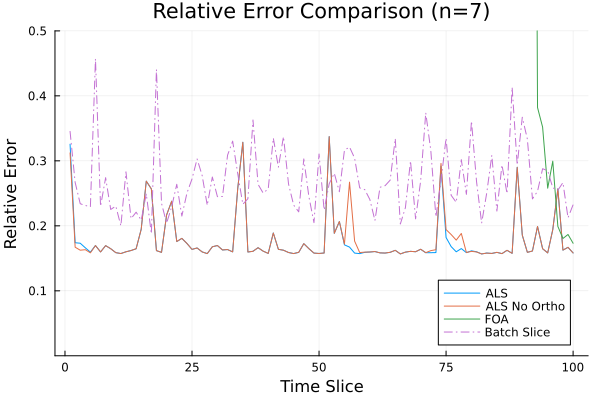

In [6]:
plot(1:T, relative_error_ALS, label="ALS")
plot!(1:T, relative_error_ALS_no_ortho, label="ALS No Ortho")
plot!(1:T, relative_error_FOA, label="FOA")
# plot!(1:T, [relative_error_batch_full for _ in 1:T], label="Batch Full", linestyle=:dash)
plot!(1:T, relative_error_batchSlice, label="Batch Slice", linestyle=:dashdot)
xlabel!("Time Slice")
ylabel!("Relative Error")
ylims!(1e-10, 0.5)
title!("Relative Error Comparison (n=$(n))")

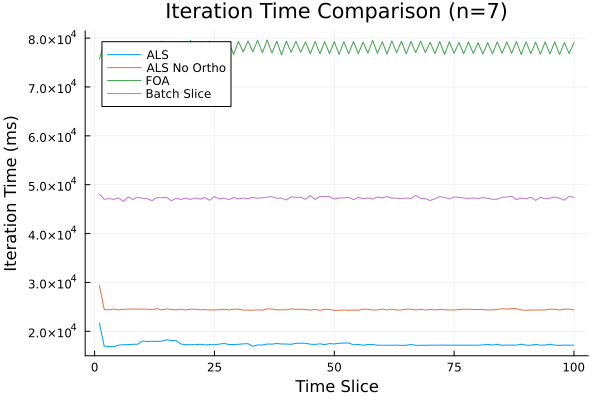

In [7]:
plot(1:T, iter_times_ALS, label="ALS")
plot!(1:T, iter_times_ALS_no_ortho, label="ALS No Ortho")
plot!(1:T, iter_times_FOA, label="FOA")
# plot!(1:T, [iter_time_batch for _ in 1:T], label="Batch Full")
plot!(1:T, iter_times_batchSlice, label="Batch Slice")
xlabel!("Time Slice")
ylabel!("Iteration Time (ms)")
title!("Iteration Time Comparison (n=$(n))")

In [8]:
relative_error_ALS[end], relative_error_ALS_no_ortho[end]

(0.15822978692174722, 0.15823704209448114)

In [ ]:
# Quantitative Evaluation: Markdown Table Generation
# ---------------------------------------------------------
# Automatically generate the Markdown,
# demonstrating the algorithmic scalability, convergence accuracy, and the 
# critical necessity of the orthogonal gauge constraint.
T = 100
avg_time_batch = iter_time_batch / T 

println("\n**Table 1: Performance on 5th-order synthetic data (n=5, T=100)**")
println("| Method | Avg. Time per Frame (ms) | Final Rel. Error (Avg t=91-100) |")
println("| :--- | :--- | :--- |")
@printf("| **Proposed (Online TT-ALS)** | %.2f | %.4e |\n", mean(iter_times_ALS), mean(relative_error_ALS[91:100]))
@printf("| TT-FOA | %.2f | %.4e |\n", mean(iter_times_FOA), mean(relative_error_FOA[91:100]))
@printf("| TT-ALS (Slice) | %.2f | %.4e |\n", mean(iter_times_batchSlice), mean(relative_error_batchSlice[91:100]))
@printf("| Batch TT-ALS (Full)* | %.2f | %.4e |\n", avg_time_batch, mean(relative_error_batch_full))

println("\n**Table 2: Ablation of the orthogonalization constraint (Relative Error)**")
println("| Method | t=10 | t=50 | t=100 |")
println("| :--- | :--- | :--- | :--- |")
@printf("| **Proposed (with Ortho)** | %.4e | %.4e | %.4e |\n", relative_error_ALS[10], relative_error_ALS[50], relative_error_ALS[100])
@printf("| Proposed (without Ortho) | %.4e | %.4e | %.4e |\n", relative_error_ALS_no_ortho[10], relative_error_ALS_no_ortho[50], relative_error_ALS_no_ortho[100])

=== コピー＆ペースト用 Markdown 表 ===

**Table 1: Performance on 5th-order synthetic data (n=5, T=100)**
| Method | Avg. Time per Frame (ms) | Final Rel. Error (Avg t=91-100) |
| :--- | :--- | :--- |
| **Proposed (Online TT-ALS)** | 178.87 | 1.4302e-02 |
| TT-FOA | 1219.94 | 1.4568e-02 |
| TT-ALS (Slice) | 289.62 | 2.3784e-02 |
| Batch TT-ALS (Full)* | 371.33 | 1.8258e-02 |

**Table 2: Ablation of the orthogonalization constraint (Relative Error)**
| Method | t=10 | t=50 | t=100 |
| :--- | :--- | :--- | :--- |
| **Proposed (with Ortho)** | 1.0928e-02 | 1.0974e-02 | 1.2945e-02 |
| Proposed (without Ortho) | 1.0909e-02 | 2.6066e-02 | 1.2468e-01 |


In [ ]:
println("\n**Table 1: Performance on 5th-order synthetic data (n=5, T=100)**")
println("| Method | Avg. Time per Frame (ms) | Final Rel. Error (Avg t=91-100) |")
println("| :--- | :--- | :--- |")
@printf("| **Proposed (Online TT-ALS)** | %.2f | %.5f |\n", mean(iter_times_ALS), mean(relative_error_ALS[91:100]))
@printf("| TT-FOA | %.2f | %.5f |\n", mean(iter_times_FOA), mean(relative_error_FOA[91:100]))
@printf("| TT-ALS (Slice) | %.2f | %.5f |\n", mean(iter_times_batchSlice), mean(relative_error_batchSlice[91:100]))
@printf("| Batch TT-ALS (Full)* | %.2f | %.5f |\n", avg_time_batch, mean(relative_error_batch_full))

println("\n**Table 2: Ablation of the orthogonalization constraint (Relative Error)**")
println("| Method | t=10 | t=50 | t=100 |")
println("| :--- | :--- | :--- | :--- |")
@printf("| **Proposed (with Ortho)** | %.5f | %.5f | %.5f |\n", relative_error_ALS[10], relative_error_ALS[50], relative_error_ALS[100])
@printf("| Proposed (without Ortho) | %.5f | %.5f | %.5f |\n", relative_error_ALS_no_ortho[10], relative_error_ALS_no_ortho[50], relative_error_ALS_no_ortho[100])

=== コピー＆ペースト用 Markdown 表 ===

**Table 1: Performance on 5th-order synthetic data (n=5, T=100)**
| Method | Avg. Time per Frame (ms) | Final Rel. Error (Avg t=91-100) |
| :--- | :--- | :--- |
| **Proposed (Online TT-ALS)** | 178.87 | 0.01430 |
| TT-FOA | 1219.94 | 0.01457 |
| TT-ALS (Slice) | 289.62 | 0.02378 |
| Batch TT-ALS (Full)* | 371.33 | 0.01826 |

**Table 2: Ablation of the orthogonalization constraint (Relative Error)**
| Method | t=10 | t=50 | t=100 |
| :--- | :--- | :--- | :--- |
| **Proposed (with Ortho)** | 0.01093 | 0.01097 | 0.01294 |
| Proposed (without Ortho) | 0.01091 | 0.02607 | 0.12468 |
